# Web Scraping

In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd

service = Service('C:/Users/najla/Downloads/WebDrivers/chromedriver.exe')
options = webdriver.ChromeOptions()
options.add_argument("--headless")
driver = webdriver.Chrome(service=service, options=options)

# Base URL with pagination
base_url = "https://dream2000.com/mobiles.html?page="
data = []
wait = WebDriverWait(driver, 15)
MAX_RETRIES = 3  # Number of retries per page

# Loop through pages 1 to 10
for page in range(1, 11):
    retries = 0
    success = False

    while retries < MAX_RETRIES and not success:
        url = base_url + str(page)
        driver.get(url)
        try:
            # Wait for at least one product name to be present
            wait.until(EC.presence_of_element_located((By.XPATH, "//a[contains(@class,'product-item-link')]")))

            products = driver.find_elements(By.XPATH, "//*[contains(@class,'product-item-info')]")
            print(f"Page {page} - Found {len(products)} products")

            for product in products:
                try:
                    # Extract product name
                    name_elem = product.find_element(By.XPATH, ".//a[contains(@class,'product-item-link')]")
                    name = name_elem.text.strip()

                    # Extract price
                    price_elem = product.find_element(By.XPATH, ".//span[@class='price']")
                    price = price_elem.text.strip()

                    # Extract image URL (handle lazy-loaded images)
                    img_elem = product.find_element(By.XPATH, ".//img")
                    img_url = img_elem.get_attribute('src')

                    # If it's a placeholder SVG, try other attributes
                    if img_url.startswith("data:image"):
                        img_url = img_elem.get_attribute('data-src') or img_elem.get_attribute('srcset') or img_url

                    data.append([name, price, img_url])
                except Exception:
                    continue

            success = True  # Page scraped successfully
        except Exception:
            retries += 1
            print(f"Retry {retries} failed for page {page}")

driver.quit()

# Save data
df = pd.DataFrame(data, columns=['Name', 'Price', 'Image_URL'])
df.to_csv('mobiles_data.csv', index=False)
print("Saved as mobiles_data.csv")


Page 1 - Found 42 products
Page 2 - Found 40 products
Page 3 - Found 40 products
Page 4 - Found 40 products
Page 5 - Found 40 products
Page 6 - Found 40 products
Page 7 - Found 42 products
Page 8 - Found 40 products
Page 9 - Found 40 products
Page 10 - Found 42 products
Saved as mobiles_data.csv


# Data

In [ ]:
import pandas as pd
import re

mobilesData = pd.read_csv('mobiles_data.csv')
mobilesData

,Name,Price,Image_URL
0,ريلمي C61، رامات 4 جيجا، 128 جيجا - ذهبي لامع,"5,555 جنيه",https://dream2000.com/static/frontend/Olegnax/...
1,Itel P65 8 جيجابايت رام، 128 جيجابايت - أسود,"6,111 جنيه",https://dream2000.com/static/frontend/Olegnax/...
2,ريلمي C61، رامات 6 جيجا، 128 جيجا - أخضر غامق,"6,160 جنيه",https://dream2000.com/static/frontend/Olegnax/...
3,ريلمي C75 رامات 8 جيجا، 256 جيجا - أسود,"9,666 جنيه",https://dream2000.com/static/frontend/Olegnax/...
4,ابل ايفون 16 128 جيجا - أسود ( ضمان سنة ),"55,555 جنيه",https://dream2000.com/static/frontend/Olegnax/...
...,...,...,...
395,شاومي ريدمي نوت 14 برو، رامات 8 جيجابايت، 256 ...,"14,333 جنيه",https://dream2000.com/static/frontend/Olegnax/...
396,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,"22,999 جنيه",https://dream2000.com/static/frontend/Olegnax/...
397,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,"22,999 جنيه",https://dream2000.com/static/frontend/Olegnax/...
398,هواوي نوفا 13 برو رامات 12 جيجا، 512 جيجا بايت...,"32,999 جنيه",https://dream2000.com/static/frontend/Olegnax/...


In [ ]:
mobilesData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       400 non-null    object
 1   Price      400 non-null    object
 2   Image_URL  400 non-null    object
dtypes: object(3)
memory usage: 9.5+ KB


# Data Preprocessing

## Drop unnecessary columns


In [ ]:
mobilesData.drop(columns=["Image_URL"], inplace=True)

In [ ]:
mobilesData

,Name,Price
0,ريلمي C61، رامات 4 جيجا، 128 جيجا - ذهبي لامع,"5,555 جنيه"
1,Itel P65 8 جيجابايت رام، 128 جيجابايت - أسود,"6,111 جنيه"
2,ريلمي C61، رامات 6 جيجا، 128 جيجا - أخضر غامق,"6,160 جنيه"
3,ريلمي C75 رامات 8 جيجا، 256 جيجا - أسود,"9,666 جنيه"
4,ابل ايفون 16 128 جيجا - أسود ( ضمان سنة ),"55,555 جنيه"
...,...,...
395,شاومي ريدمي نوت 14 برو، رامات 8 جيجابايت، 256 ...,"14,333 جنيه"
396,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,"22,999 جنيه"
397,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,"22,999 جنيه"
398,هواوي نوفا 13 برو رامات 12 جيجا، 512 جيجا بايت...,"32,999 جنيه"


## Clean the 'Price' column and convert to numeric

In [ ]:
# Remove the currency word and commas, then convert to numeric
mobilesData["Price"] = mobilesData["Price"].str.replace("جنيه", "", regex=False)
mobilesData["Price"] = mobilesData["Price"].str.replace(",", "", regex=False).str.strip()
mobilesData["Price"] = pd.to_numeric(mobilesData["Price"], errors="coerce")


In [ ]:
mobilesData

,Name,Price
0,ريلمي C61، رامات 4 جيجا، 128 جيجا - ذهبي لامع,5555
1,Itel P65 8 جيجابايت رام، 128 جيجابايت - أسود,6111
2,ريلمي C61، رامات 6 جيجا، 128 جيجا - أخضر غامق,6160
3,ريلمي C75 رامات 8 جيجا، 256 جيجا - أسود,9666
4,ابل ايفون 16 128 جيجا - أسود ( ضمان سنة ),55555
...,...,...
395,شاومي ريدمي نوت 14 برو، رامات 8 جيجابايت، 256 ...,14333
396,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999
397,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999
398,هواوي نوفا 13 برو رامات 12 جيجا، 512 جيجا بايت...,32999


## Extract the brand from the 'Name' column

In [ ]:
# Extract the first word as the brand
mobilesData["Brand"] = mobilesData["Name"].str.extract(r"^(\S+)")


In [ ]:
mobilesData

,Name,Price,Brand
0,ريلمي C61، رامات 4 جيجا، 128 جيجا - ذهبي لامع,5555,ريلمي
1,Itel P65 8 جيجابايت رام، 128 جيجابايت - أسود,6111,Itel
2,ريلمي C61، رامات 6 جيجا، 128 جيجا - أخضر غامق,6160,ريلمي
3,ريلمي C75 رامات 8 جيجا، 256 جيجا - أسود,9666,ريلمي
4,ابل ايفون 16 128 جيجا - أسود ( ضمان سنة ),55555,ابل
...,...,...,...
395,شاومي ريدمي نوت 14 برو، رامات 8 جيجابايت، 256 ...,14333,شاومي
396,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي
397,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي
398,هواوي نوفا 13 برو رامات 12 جيجا، 512 جيجا بايت...,32999,هواوي


##  Extract RAM (in GB) from the 'Name' column


In [ ]:
# Extract two possible RAM patterns (e.g., "رام 4 جيجا" or "4 جيجا رام")
ram_extract = mobilesData["Name"].str.extract(
    r"(?:رام(?:ات)?\s*(\d+)\s*جيجا(?:بايت)?)|(\d+)\s*جيجا(?:بايت)?\s*رام"
)

# Select the first non-null value between the two extracted columns
mobilesData["RAM_GB"] = ram_extract[0].combine_first(ram_extract[1])

# Convert RAM values to numeric
mobilesData["RAM_GB"] = pd.to_numeric(mobilesData["RAM_GB"], errors="coerce")


In [ ]:
mobilesData

,Name,Price,Brand,RAM_GB
0,ريلمي C61، رامات 4 جيجا، 128 جيجا - ذهبي لامع,5555,ريلمي,4.0
1,Itel P65 8 جيجابايت رام، 128 جيجابايت - أسود,6111,Itel,8.0
2,ريلمي C61، رامات 6 جيجا، 128 جيجا - أخضر غامق,6160,ريلمي,6.0
3,ريلمي C75 رامات 8 جيجا، 256 جيجا - أسود,9666,ريلمي,8.0
4,ابل ايفون 16 128 جيجا - أسود ( ضمان سنة ),55555,ابل,NaN
...,...,...,...,...
395,شاومي ريدمي نوت 14 برو، رامات 8 جيجابايت، 256 ...,14333,شاومي,8.0
396,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي,12.0
397,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي,12.0
398,هواوي نوفا 13 برو رامات 12 جيجا، 512 جيجا بايت...,32999,هواوي,12.0


## Extract storage (in GB) from the 'Name' column


In [ ]:
# Extract all numbers followed by the word "جيجا" or "جيجابايت"
gigabytes = mobilesData["Name"].str.findall(r"(\d+)\s*جيجا(?:بايت)?")

# Try to take the second number if it exists (assuming the first is usually the RAM)
mobilesData["Storage_GB"] = gigabytes.apply(
    lambda x: int(x[1]) if len(x) > 1 else (int(x[0]) if len(x) == 1 else None)
)


In [ ]:
mobilesData

,Name,Price,Brand,RAM_GB,Storage_GB
0,ريلمي C61، رامات 4 جيجا، 128 جيجا - ذهبي لامع,5555,ريلمي,4.0,128
1,Itel P65 8 جيجابايت رام، 128 جيجابايت - أسود,6111,Itel,8.0,128
2,ريلمي C61، رامات 6 جيجا، 128 جيجا - أخضر غامق,6160,ريلمي,6.0,128
3,ريلمي C75 رامات 8 جيجا، 256 جيجا - أسود,9666,ريلمي,8.0,256
4,ابل ايفون 16 128 جيجا - أسود ( ضمان سنة ),55555,ابل,NaN,128
...,...,...,...,...,...
395,شاومي ريدمي نوت 14 برو، رامات 8 جيجابايت، 256 ...,14333,شاومي,8.0,256
396,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي,12.0,256
397,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي,12.0,256
398,هواوي نوفا 13 برو رامات 12 جيجا، 512 جيجا بايت...,32999,هواوي,12.0,512


## Extract color from the 'Name' column


In [ ]:
# Extract the color from the end of the name (after the dash)
mobilesData["Color"] = mobilesData["Name"].str.extract(r"-\s*(.+)$")


In [ ]:
mobilesData

,Name,Price,Brand,RAM_GB,Storage_GB,Color
0,ريلمي C61، رامات 4 جيجا، 128 جيجا - ذهبي لامع,5555,ريلمي,4.0,128,ذهبي لامع
1,Itel P65 8 جيجابايت رام، 128 جيجابايت - أسود,6111,Itel,8.0,128,أسود
2,ريلمي C61، رامات 6 جيجا، 128 جيجا - أخضر غامق,6160,ريلمي,6.0,128,أخضر غامق
3,ريلمي C75 رامات 8 جيجا، 256 جيجا - أسود,9666,ريلمي,8.0,256,أسود
4,ابل ايفون 16 128 جيجا - أسود ( ضمان سنة ),55555,ابل,NaN,128,أسود ( ضمان سنة )
...,...,...,...,...,...,...
395,شاومي ريدمي نوت 14 برو، رامات 8 جيجابايت، 256 ...,14333,شاومي,8.0,256,أسود
396,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي,12.0,256,أخضر مع هدية مجانية هواوي فري بادز SE 2
397,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي,12.0,256,أسود مع هدية مجانية هواوي فري بادز SE 2
398,هواوي نوفا 13 برو رامات 12 جيجا، 512 جيجا بايت...,32999,هواوي,12.0,512,أسود مع هدية مجانية هواوي فريبدز 5i


In [ ]:
mobilesData.isna().sum()


Name            0
Price           0
Brand           0
RAM_GB        120
Storage_GB      0
Color           0
dtype: int64

In [ ]:
mobilesData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        400 non-null    object 
 1   Price       400 non-null    int64  
 2   Brand       400 non-null    object 
 3   RAM_GB      280 non-null    float64
 4   Storage_GB  400 non-null    int64  
 5   Color       400 non-null    object 
dtypes: float64(1), int64(2), object(3)
memory usage: 18.9+ KB


In [ ]:
## تجيهز ملف الداتا عشان يفتح في الويكا

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_weka = mobilesData.copy()

le = LabelEncoder()
for col in df_weka.select_dtypes(include='object').columns:
    df_weka[col] = le.fit_transform(df_weka[col])


In [ ]:
df_weka.to_csv("Data_For_Weka.csv", index=False, encoding='utf-8')


## Handle missing data

In [ ]:
mobilesData["RAM_GB"].fillna(mobilesData["RAM_GB"].median(), inplace=True)


In [ ]:
mobilesData.isna().sum()


Name          0
Price         0
Brand         0
RAM_GB        0
Storage_GB    0
Color         0
dtype: int64

## Outliers Treatment (IQR)

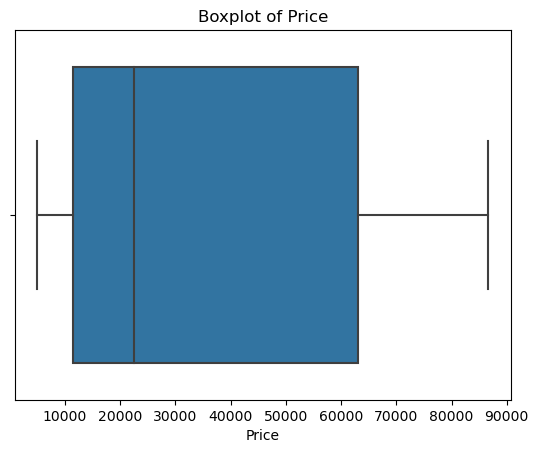

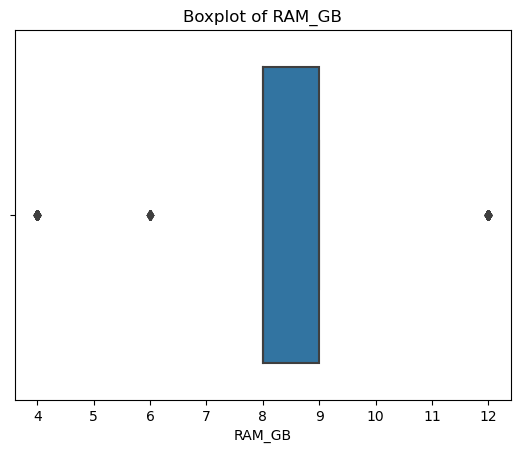

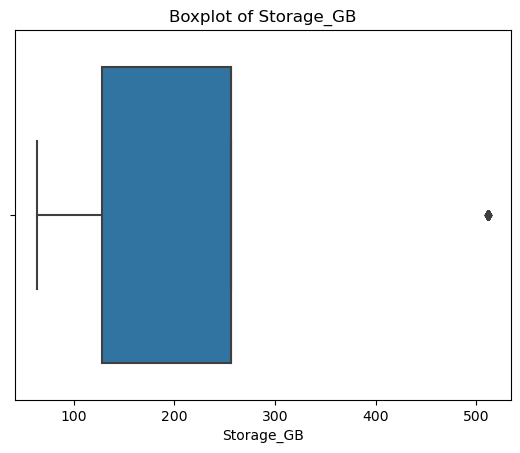

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['Price', 'RAM_GB', 'Storage_GB']:
    plt.figure()
    sns.boxplot(data=mobilesData, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = mobilesData.copy()

columns_to_fix = ['RAM_GB', 'Storage_GB']

for col in columns_to_fix:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    # clip the values to the bounds
    data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

    # count the number of outliers after clipping
    outlier_count_after = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()

    print(f"{col}:")
    print(f"Number of outliers after modification: {outlier_count_after}\n")




RAM_GB:
Number of outliers after modification: 0

Storage_GB:
Number of outliers after modification: 0



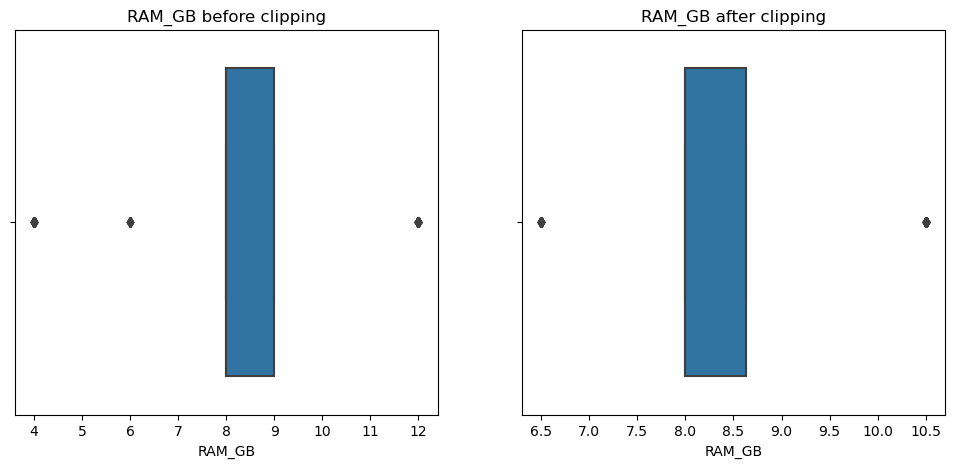

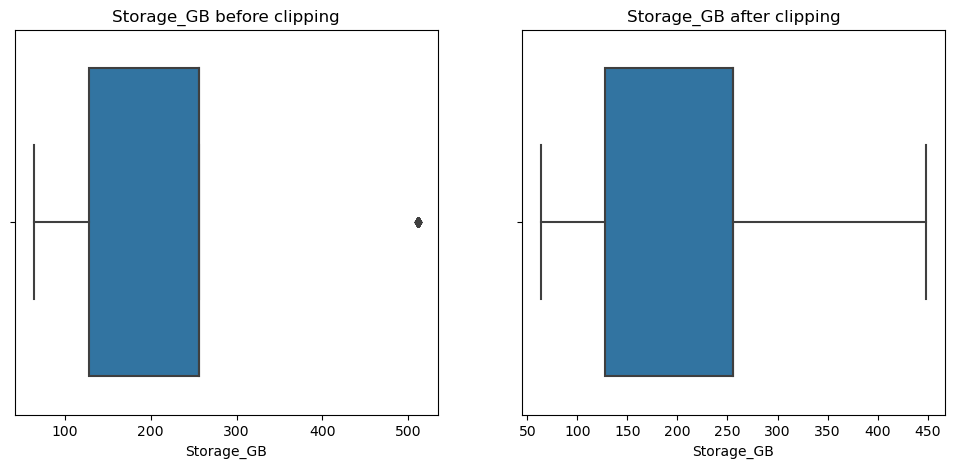

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in columns_to_fix:
    plt.figure(figsize=(12, 5))

    # Boxplot before clipping
    plt.subplot(1, 2, 1)
    sns.boxplot(x=mobilesData[col])
    plt.title(f'{col} before clipping')

    # Boxplot after clipping
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col])
    plt.title(f'{col} after clipping')

    plt.show()


## Feature Scaling (Normalization)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaledData = mobilesData.copy()
scaledData[[ 'RAM_GB', 'Storage_GB']] = scaler.fit_transform(
    scaledData[[ 'RAM_GB', 'Storage_GB']]
)


In [ ]:
scaledData

,Name,Price,Brand,RAM_GB,Storage_GB,Color
0,ريلمي C61، رامات 4 جيجا، 128 جيجا - ذهبي لامع,5555,ريلمي,0.00,0.142857,ذهبي لامع
1,Itel P65 8 جيجابايت رام، 128 جيجابايت - أسود,6111,Itel,0.50,0.142857,أسود
2,ريلمي C61، رامات 6 جيجا، 128 جيجا - أخضر غامق,6160,ريلمي,0.25,0.142857,أخضر غامق
3,ريلمي C75 رامات 8 جيجا، 256 جيجا - أسود,9666,ريلمي,0.50,0.428571,أسود
4,ابل ايفون 16 128 جيجا - أسود ( ضمان سنة ),55555,ابل,0.50,0.142857,أسود ( ضمان سنة )
...,...,...,...,...,...,...
395,شاومي ريدمي نوت 14 برو، رامات 8 جيجابايت، 256 ...,14333,شاومي,0.50,0.428571,أسود
396,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي,1.00,0.428571,أخضر مع هدية مجانية هواوي فري بادز SE 2
397,هواوي نوفا 13، رامات 12 جيجابايت، 256 جيجابايت...,22999,هواوي,1.00,0.428571,أسود مع هدية مجانية هواوي فري بادز SE 2
398,هواوي نوفا 13 برو رامات 12 جيجا، 512 جيجا بايت...,32999,هواوي,1.00,1.000000,أسود مع هدية مجانية هواوي فريبدز 5i


## Encoding Categorical Features

In [ ]:
# Perform One-Hot Encoding on 'Brand' and 'Color'
data_encoded = pd.get_dummies(data, columns=['Brand', 'Color'], drop_first=True)

# Show the resulting columns
print("Encoded dataset columns:", data_encoded.columns.tolist())

# Preview the encoded dataset
data_encoded.head()
# data_encoded.shape

Encoded dataset columns: ['Name', 'Price', 'RAM_GB', 'Storage_GB', 'Brand_آيفون', 'Brand_ابل', 'Brand_ريلمي', 'Brand_سامسونج', 'Brand_شاومي', 'Brand_فيفو', 'Brand_هواوي', 'Brand_هونر', 'Color_أبيض ( ضمان سنة )', 'Color_أخضر', 'Color_أخضر غامق', 'Color_أخضر مع هدية مجانية هواوي فري بادز SE 2', 'Color_أخضر مع هدية مجانية هواوي فريبدز 5i', 'Color_أزرق', 'Color_أسود', 'Color_أسود ( ضمان سنة )', 'Color_أسود تيتانيوم ( ضمان سنة )', 'Color_أسود مع هدية مجانية هواوي فري بادز SE 2', 'Color_أسود مع هدية مجانية هواوي فريبدز 5i', 'Color_ألترامارين (ضمان سنة)', 'Color_ابيض (ضمان سنة )', 'Color_اسود (ضمان سنة)', 'Color_بنفسجي', 'Color_تاتنيوم جولد', 'Color_تيتانيوم ( ضمان سنة )', 'Color_ذهبى ( ضمان سنة )', 'Color_ذهبي لامع']


,Name,Price,RAM_GB,Storage_GB,Brand_آيفون,Brand_ابل,Brand_ريلمي,Brand_سامسونج,Brand_شاومي,Brand_فيفو,...,Color_أسود مع هدية مجانية هواوي فري بادز SE 2,Color_أسود مع هدية مجانية هواوي فريبدز 5i,Color_ألترامارين (ضمان سنة),Color_ابيض (ضمان سنة ),Color_اسود (ضمان سنة),Color_بنفسجي,Color_تاتنيوم جولد,Color_تيتانيوم ( ضمان سنة ),Color_ذهبى ( ضمان سنة ),Color_ذهبي لامع
0,ريلمي C61، رامات 4 جيجا، 128 جيجا - ذهبي لامع,5555,6.5,128,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,Itel P65 8 جيجابايت رام، 128 جيجابايت - أسود,6111,8.0,128,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ريلمي C61، رامات 6 جيجا، 128 جيجا - أخضر غامق,6160,6.5,128,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ريلمي C75 رامات 8 جيجا، 256 جيجا - أسود,9666,8.0,256,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ابل ايفون 16 128 جيجا - أسود ( ضمان سنة ),55555,8.0,128,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data_encoded.to_csv('preprocessed_data.csv', index=False)


## Train-Test Split & Regression Modeling

In [ ]:
from sklearn.model_selection import train_test_split

#  Separate features and target
X = data_encoded.drop(['Price', 'Name'], axis=1)
y = data_encoded['Price']

#  Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



## Model 1 :
**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Linear Regression:
Mean Absolute Error (MAE): 1080.8074
Mean Squared Error (MSE): 3614227.6212
Root Mean Squared Error (RMSE): 1901.1122


## Model 2 :
**Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest Regressor:")
print(f"MAE: {mae_rf:.4f}")
print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")


Random Forest Regressor:
MAE: 39.7783
MSE: 126584.9533
RMSE: 355.7878


# Model 3 :
**Support Vector Regressor (SVR)**

In [ ]:
from sklearn.svm import SVR

# Initialize and train the model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Predict
y_pred_svr = svr_model.predict(X_test)

# Evaluate
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print("Support Vector Regressor (SVR):")
print(f"MAE: {mae_svr:.4f}")
print(f"MSE: {mse_svr:.4f}")
print(f"RMSE: {rmse_svr:.4f}")


Support Vector Regressor (SVR):
MAE: 25059.6370
MSE: 1111941246.1504
RMSE: 33345.7830


## Model Comparison

Three regression models were trained to predict phone prices:

| Model                   | MAE     | MSE     | RMSE    |
|------------------------|---------|---------|---------|
| Linear Regression      | 1080.8074  | 3614227.6212 | 1901.1122  |
| **Random Forest**      | **39.7783** | **126584.9533** | **355.7878** |
| SVR (RBF Kernel)       | 25059.6370  | 1111941246.1504  | 33345.7830  |

**Conclusion:**  
- **Random Forest** performed best with the lowest error.
- **Linear Regression** gave decent results.
- **SVR** underperformed, likely due to default hyperparameters.

**Recommendation:** Use Random Forest as the primary model.


## Feature Selection via Correlation Matrix

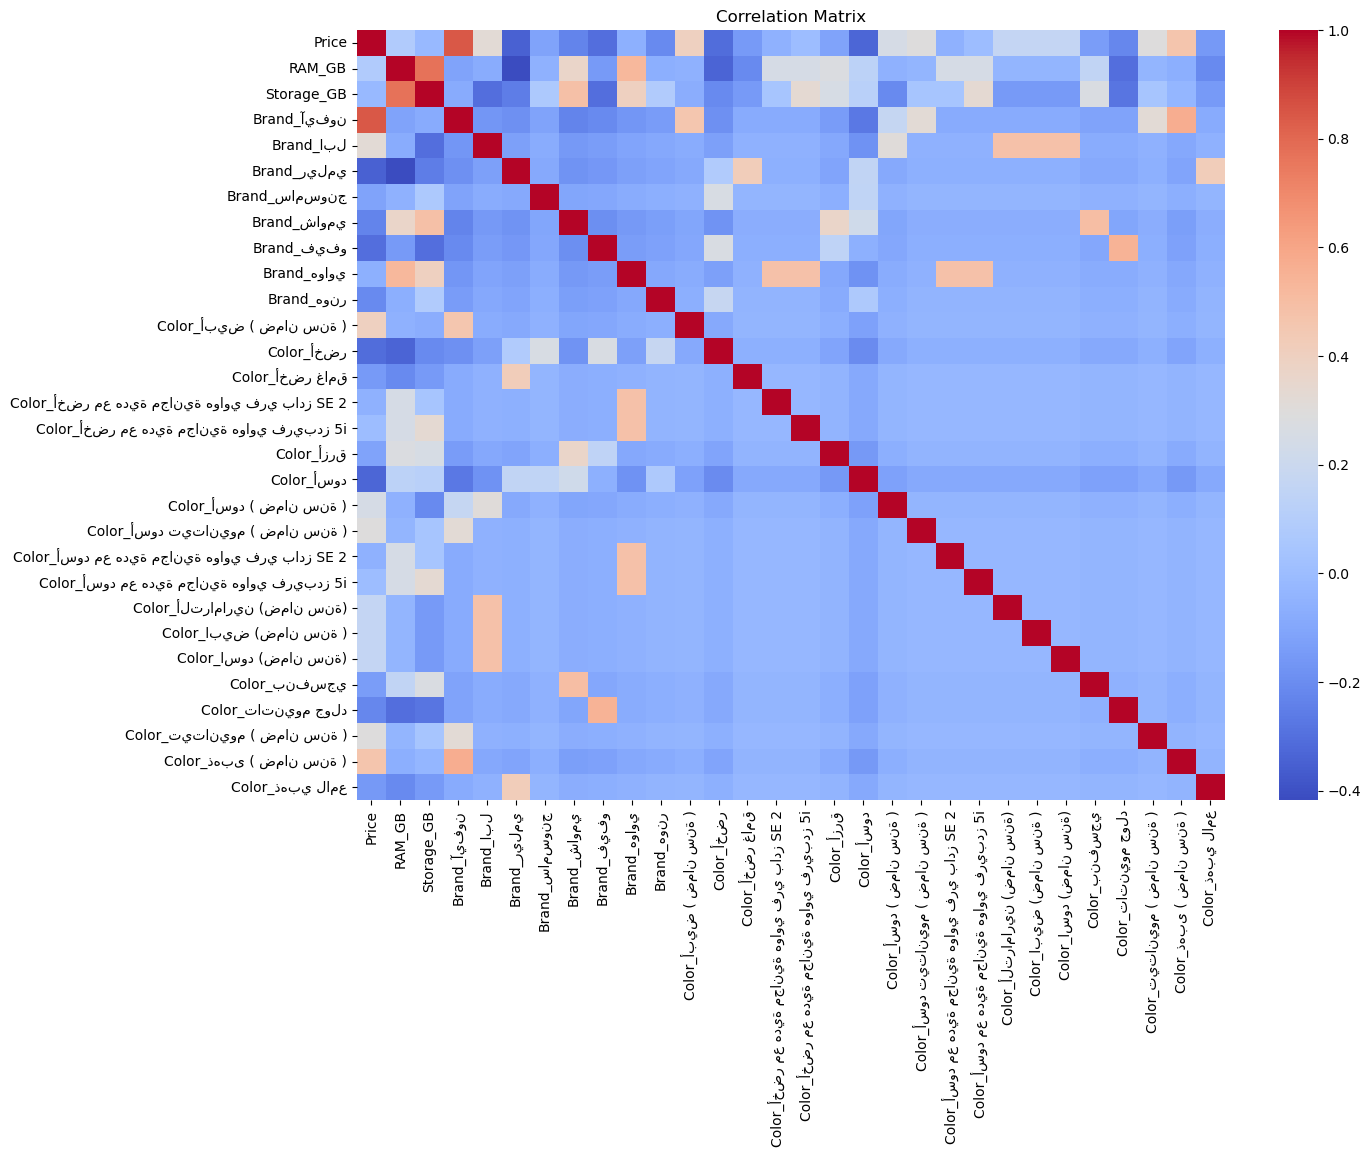

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix for numerical features
corr_matrix = data_encoded.corr(numeric_only=True)

# Plot the correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
# Get the upper triangle of the correlation matrix (to avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns with high correlation
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.8)]

print("Highly correlated features to drop:", to_drop)


Highly correlated features to drop: ['Brand_آيفون']


In [ ]:
# Retrain Random Forest on the reduced dataset
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred_rf = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"After Feature Selection - MAE: {mae:.4f}, RMSE: {rmse:.4f}")


After Feature Selection - MAE: 39.7783, RMSE: 355.7878


## Dimensionality Reduction via PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Separate features and target variable
X = data_encoded.drop(['Price', 'Name'], axis=1)
y = data_encoded['Price']

# Apply PCA
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)

# Print original and reduced feature counts
print(f"Original number of features: {X.shape[1]}")
print(f"Reduced number of features after PCA: {X_pca.shape[1]}")

# Split the PCA-transformed data into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Train a Random Forest model on the PCA
rf_pca = RandomForestRegressor(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)

# Predict
y_pred_rf_pca = rf_pca.predict(X_test_pca)

# Evaluate the model's performance using MAE, MSE, and RMSE
mae_pca = mean_absolute_error(y_test, y_pred_rf_pca)
mse_pca = mean_squared_error(y_test, y_pred_rf_pca)
rmse_pca = np.sqrt(mse_pca)

# Print evaluation metrics
print("Random Forest after PCA:")
print(f"MAE: {mae_pca:.4f}")
print(f"MSE: {mse_pca:.4f}")
print(f"RMSE: {rmse_pca:.4f}")


Original number of features: 29
Reduced number of features after PCA: 10
Random Forest after PCA:
MAE: 58.9700
MSE: 132509.4311
RMSE: 364.0184


### PCA Results Summary

- PCA reduced the features from **29 to 10**
- **Random Forest still performed well**, as it handles high-dimensional data well.

###  Conclusion

- If you want **higher accuracy**, PCA is **not necessary**.
- If you prefer a **simpler and faster model** with slight accuracy loss, PCA is a **good option**.


# Comparative Analysis

#### Best Performing Algorithm:
- **Random Forest Regressor** achieved the **lowest error values**:
  - MAE: 39.7783
  - RMSE: 355.7878
- It consistently outperformed both **Linear Regression** and **SVR**.

#### Effect of Feature Selection:
- **Correlation-based feature removal** (e.g., dropping highly correlated features like `Brand_آيفون`) had **no significant impact** on performance.
- **PCA**  had **no effect** on **Random Forest**.

#### Conclusion:
- **Random Forest** is the recommended model for predicting mobile prices.
- **Feature selection** (correlation/PCA) is useful for simplifying models, but not critical when using Random Forest.
